<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/DL_Lab_exp_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Experiment 3: Learning WITHOUT Backpropagation...
Initial Error (Random Weights): 1.0072
Training with Hill Climbing (Mutation)...
Final Error after 1000 mutations: 0.0000


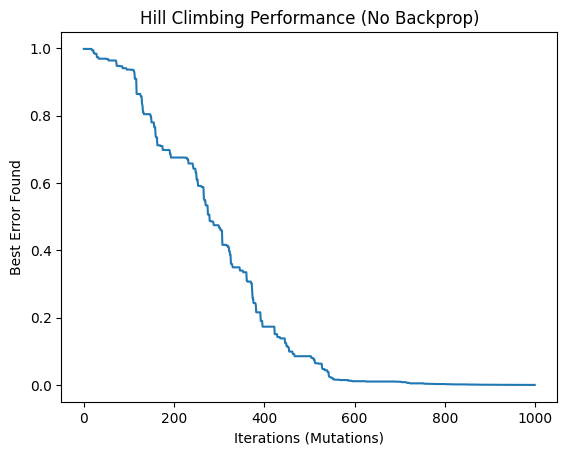


--- Predictions from Mutated Network ---
Input: [0, 0], Expected: 0, Predicted: 0.0022
Input: [0, 1], Expected: 1, Predicted: 0.9964
Input: [1, 0], Expected: 1, Predicted: 0.9966
Input: [1, 1], Expected: 0, Predicted: 0.0044


In [1]:
import random
import math
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Structure Only - NO Backprop)
# ==========================================
def sigmoid(x):
    # Safe Sigmoid to prevent overflow
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Note: We don't need 'velocity' or 'delta' anymore! Just weights.
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def calculate_total_error(network, dataset):
    sum_error = 0
    for row in dataset:
        outputs = forward_propagate(network, row[:-1])
        expected = [row[-1]]
        sum_error += (expected[0] - outputs[0])**2
    return sum_error

# ==========================================
# 2. THE "NO BACKPROP" LEARNING ALGORITHMS
# ==========================================

# Technique A: Hill Climbing (The "Mutate & Check" Method)
def train_hill_climbing(network, dataset, n_iterations, mutation_rate):
    history = []
    best_error = calculate_total_error(network, dataset)

    for i in range(n_iterations):
        # 1. Create a copy of the network (The "Child")
        child_network = copy.deepcopy(network)

        # 2. Mutate the Child (Randomly tweak weights)
        for layer in child_network:
            for neuron in layer:
                for j in range(len(neuron['weights'])):
                    # 50% chance to modify a weight
                    if random.random() < 0.5:
                        # Add random noise (Mutation)
                        change = random.uniform(-mutation_rate, mutation_rate)
                        neuron['weights'][j] += change

        # 3. Test the Child
        child_error = calculate_total_error(child_network, dataset)

        # 4. Survival of the Fittest
        if child_error < best_error:
            # Child is better! Keep it.
            network = child_network
            best_error = child_error

        # (Else: Child was worse. Discard it and keep old network)
        history.append(best_error)

    return history, network

# ==========================================
# 3. EXECUTION & COMPARISON
# ==========================================
# Dataset: XOR Problem (Simple enough for random guessing to solve)
dataset = [
    [0,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0]
]

print("Running Experiment 3: Learning WITHOUT Backpropagation...")

# Initialize
network = initialize_network(2, 4, 1) # 2 Inputs -> 4 Hidden -> 1 Output
initial_error = calculate_total_error(network, dataset)
print(f"Initial Error (Random Weights): {initial_error:.4f}")

# Train using Hill Climbing
# mutation_rate=0.5 means we can tweak weights by up to +0.5 or -0.5
print("Training with Hill Climbing (Mutation)...")
error_history, trained_network = train_hill_climbing(network, dataset, n_iterations=1000, mutation_rate=0.5)

final_error = error_history[-1]
print(f"Final Error after 1000 mutations: {final_error:.4f}")

# Plot
plt.plot(error_history)
plt.title('Hill Climbing Performance (No Backprop)')
plt.xlabel('Iterations (Mutations)')
plt.ylabel('Best Error Found')
plt.show()

# Test Predictions
print("\n--- Predictions from Mutated Network ---")
for row in dataset:
    pred = forward_propagate(trained_network, row[:-1])[0]
    print(f"Input: {row[:-1]}, Expected: {row[-1]}, Predicted: {pred:.4f}")

Running Experiment 3: Learning WITHOUT Backpropagation...
Initial Error (Random Weights): 1.0181
Training with Hill Climbing (Mutation)...
Final Error after 1000 mutations: 1.0181


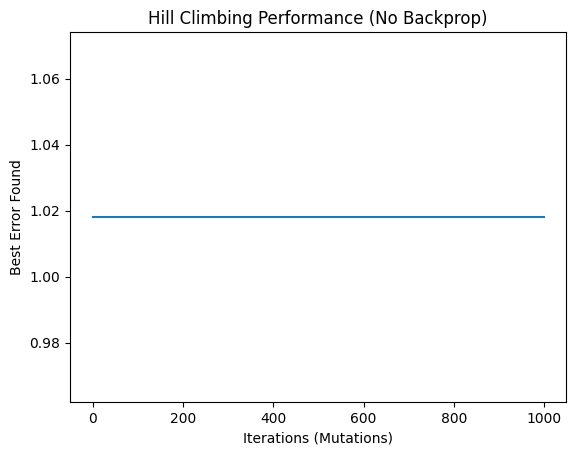


--- Predictions from Mutated Network ---
Input: [0, 0], Expected: 0, Predicted: 0.5794
Input: [0, 1], Expected: 1, Predicted: 0.5580
Input: [1, 0], Expected: 1, Predicted: 0.5715
Input: [1, 1], Expected: 0, Predicted: 0.5509


In [2]:
import random
import math
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Structure Only - NO Backprop)
# ==========================================
def sigmoid(x):
    # Safe Sigmoid to prevent overflow
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Note: We don't need 'velocity' or 'delta' anymore! Just weights.
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def calculate_total_error(network, dataset):
    sum_error = 0
    for row in dataset:
        outputs = forward_propagate(network, row[:-1])
        expected = [row[-1]]
        sum_error += (expected[0] - outputs[0])**2
    return sum_error

# ==========================================
# 2. THE "NO BACKPROP" LEARNING ALGORITHMS
# ==========================================

# Technique A: Hill Climbing (The "Mutate & Check" Method)
def train_hill_climbing(network, dataset, n_iterations, mutation_rate):
    history = []
    best_error = calculate_total_error(network, dataset)

    for i in range(n_iterations):
        # 1. Create a copy of the network (The "Child")
        child_network = copy.deepcopy(network)

        # 2. Mutate the Child (Randomly tweak weights)
        for layer in child_network:
            for neuron in layer:
                for j in range(len(neuron['weights'])):
                    # 50% chance to modify a weight
                    if random.random() < 0.5:
                        # Add random noise (Mutation)
                        change = random.uniform(-mutation_rate, mutation_rate)
                        neuron['weights'][j] += change

        # 3. Test the Child
        child_error = calculate_total_error(child_network, dataset)

        # 4. Survival of the Fittest
        if child_error < best_error:
            # Child is better! Keep it.
            network = child_network
            best_error = child_error

        # (Else: Child was worse. Discard it and keep old network)
        history.append(best_error)

    return history, network

# ==========================================
# 3. EXECUTION & COMPARISON
# ==========================================
# Dataset: XOR Problem (Simple enough for random guessing to solve)
dataset = [
    [0,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0]
]

print("Running Experiment 3: Learning WITHOUT Backpropagation...")

# Initialize
network = initialize_network(2, 4, 1) # 2 Inputs -> 4 Hidden -> 1 Output
initial_error = calculate_total_error(network, dataset)
print(f"Initial Error (Random Weights): {initial_error:.4f}")

# Train using Hill Climbing
# mutation_rate=0.5 means we can tweak weights by up to +0.5 or -0.5
print("Training with Hill Climbing (Mutation)...")
error_history, trained_network = train_hill_climbing(network, dataset, n_iterations=1000, mutation_rate=0.0)

final_error = error_history[-1]
print(f"Final Error after 1000 mutations: {final_error:.4f}")

# Plot
plt.plot(error_history)
plt.title('Hill Climbing Performance (No Backprop)')
plt.xlabel('Iterations (Mutations)')
plt.ylabel('Best Error Found')
plt.show()

# Test Predictions
print("\n--- Predictions from Mutated Network ---")
for row in dataset:
    pred = forward_propagate(trained_network, row[:-1])[0]
    print(f"Input: {row[:-1]}, Expected: {row[-1]}, Predicted: {pred:.4f}")

Running Experiment 3: Learning WITHOUT Backpropagation...
Initial Error (Random Weights): 1.0407
Training with Hill Climbing (Mutation)...
Final Error after 1000 mutations: 0.0000


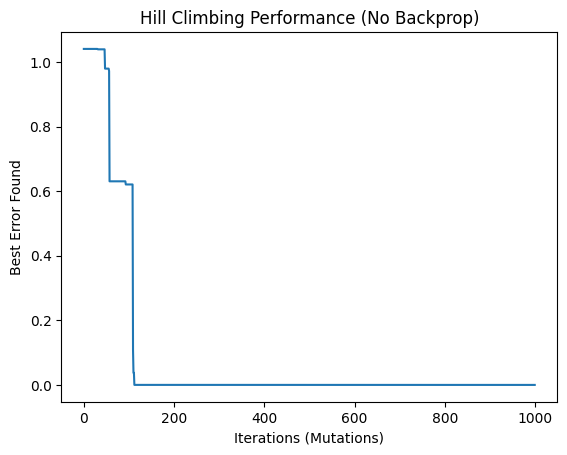


--- Predictions from Mutated Network ---
Input: [0, 0], Expected: 0, Predicted: 0.0000
Input: [0, 1], Expected: 1, Predicted: 1.0000
Input: [1, 0], Expected: 1, Predicted: 1.0000
Input: [1, 1], Expected: 0, Predicted: 0.0000


In [3]:
import random
import math
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Structure Only - NO Backprop)
# ==========================================
def sigmoid(x):
    # Safe Sigmoid to prevent overflow
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Note: We don't need 'velocity' or 'delta' anymore! Just weights.
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def calculate_total_error(network, dataset):
    sum_error = 0
    for row in dataset:
        outputs = forward_propagate(network, row[:-1])
        expected = [row[-1]]
        sum_error += (expected[0] - outputs[0])**2
    return sum_error

# ==========================================
# 2. THE "NO BACKPROP" LEARNING ALGORITHMS
# ==========================================

# Technique A: Hill Climbing (The "Mutate & Check" Method)
def train_hill_climbing(network, dataset, n_iterations, mutation_rate):
    history = []
    best_error = calculate_total_error(network, dataset)

    for i in range(n_iterations):
        # 1. Create a copy of the network (The "Child")
        child_network = copy.deepcopy(network)

        # 2. Mutate the Child (Randomly tweak weights)
        for layer in child_network:
            for neuron in layer:
                for j in range(len(neuron['weights'])):
                    # 50% chance to modify a weight
                    if random.random() < 0.5:
                        # Add random noise (Mutation)
                        change = random.uniform(-mutation_rate, mutation_rate)
                        neuron['weights'][j] += change

        # 3. Test the Child
        child_error = calculate_total_error(child_network, dataset)

        # 4. Survival of the Fittest
        if child_error < best_error:
            # Child is better! Keep it.
            network = child_network
            best_error = child_error

        # (Else: Child was worse. Discard it and keep old network)
        history.append(best_error)

    return history, network

# ==========================================
# 3. EXECUTION & COMPARISON
# ==========================================
# Dataset: XOR Problem (Simple enough for random guessing to solve)
dataset = [
    [0,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0]
]

print("Running Experiment 3: Learning WITHOUT Backpropagation...")

# Initialize
network = initialize_network(2, 4, 1) # 2 Inputs -> 4 Hidden -> 1 Output
initial_error = calculate_total_error(network, dataset)
print(f"Initial Error (Random Weights): {initial_error:.4f}")

# Train using Hill Climbing
# mutation_rate=0.5 means we can tweak weights by up to +0.5 or -0.5
print("Training with Hill Climbing (Mutation)...")
error_history, trained_network = train_hill_climbing(network, dataset, n_iterations=1000, mutation_rate=10)

final_error = error_history[-1]
print(f"Final Error after 1000 mutations: {final_error:.4f}")

# Plot
plt.plot(error_history)
plt.title('Hill Climbing Performance (No Backprop)')
plt.xlabel('Iterations (Mutations)')
plt.ylabel('Best Error Found')
plt.show()

# Test Predictions
print("\n--- Predictions from Mutated Network ---")
for row in dataset:
    pred = forward_propagate(trained_network, row[:-1])[0]
    print(f"Input: {row[:-1]}, Expected: {row[-1]}, Predicted: {pred:.4f}")